Your Python code **already has the recursion depth limiter**, but I’ll align it exactly with the C++ logic and explain the math + purpose clearly.

---

# 1. What changed from C++ to Python?

In C++:

```cpp
if (depth <= 0)
    return color(0,0,0);
```

In your Python:

```python
if depth <= 0:
    return Vec3(0,0,0)
```

That part is already correct.

The real changes needed:

1. Pass `depth=max_depth` from `render()`
2. Reduce depth each bounce:

   ```python
   depth - 1
   ```
3. Stop at black when depth reaches zero
4. Use safe hit interval:

   ```python
   Interval(0.001, INFINITY)
   ```

   to avoid shadow acne.

---

# Updated Python Version (matching C++)

```python
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer


class Camera:

    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50   # bounce limit

    def initialize(self):

        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    def sample_square(self):
        import random

        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    def ray_color(self, r, world, depth):

        # Bounce limit reached
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):
            direction = random_on_hemisphere(
                rec.normal
            )

            scattered_ray = Ray(
                rec.p,
                direction
            )

            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        unit_dir = unit_vector(
            r.direction()
        )

        t = 0.5 * (
            unit_dir.y + 1.0
        )

        return (
            (1.0 - t) * Vec3(1, 1, 1)
            + t * Vec3(0.5, 0.7, 1.0)
        )

    def render(self, world):

        self.initialize()

        with open("output.ppm", "w") as f:

            f.write(
                f"P3\n{self.image_width} "
                f"{self.image_height}\n255\n"
            )

            for j in tqdm(range(self.image_height)):

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    ir = int(
                        255.999 * pixel_color.x
                    )
                    ig = int(
                        255.999 * pixel_color.y
                    )
                    ib = int(
                        255.999 * pixel_color.z
                    )

                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):
        return image_viewer("output.ppm")
```

---

# Main file

```python
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 50

cam.render(world)
cam.show()
```

---

# Learning Notes (with formulas)

| Step                     | Formula                                  | Meaning                                   | Purpose                      |
| ------------------------ | ---------------------------------------- | ----------------------------------------- | ---------------------------- |
| Ray equation             | $P(t)=A+tB$                              | Ray starts at $A$, moves in direction $B$ | Finds points along ray       |
| Unit vector              | $\hat v=\frac{v}{|v|}$                   | Makes vector length 1                     | Needed for sky gradient      |
| Recursive bounce         | $L(r)=0.5L(r')$                          | New scattered ray loses half energy       | Simulates diffuse reflection |
| Depth limiting           | $d=d-1$                                  | Each bounce reduces remaining depth       | Prevents infinite recursion  |
| Stop condition           | $d \le 0$                                | Return black                              | Stack safety                 |
| Background interpolation | $C=(1-a)W+aB$                            | Blend white and blue                      | Sky coloring                 |
| Blend factor             | $a=0.5(y+1)$                             | Maps y from [-1,1] → [0,1]                | Smooth sky transition        |
| Sample averaging         | $C_{final}=\frac{1}{N}\sum_{i=1}^{N}C_i$ | Average all samples                       | Anti-aliasing                |
| Hemisphere sampling      | $$D=random(normal)$$                     | Random bounce direction                   | Diffuse light scattering     |

---

# Why recursion depth matters

Without depth limit:

```text
Ray hits sphere
→ bounces
→ hits again
→ bounces
→ hits again
→ forever
```

This can cause:

* stack overflow
* infinite render
* memory crash

With limit:

```text
Depth = 50
49
48
...
1
0 → stop
```

Safe.

---

# Formula flow of the full render

$$
Ray \rightarrow Hit?
$$

If no hit:

$$
Color=(1-a)White+aBlue
$$

If hit:

$$
Color=0.5 \times RayColor(ScatteredRay, depth-1)
$$

If depth:

$$
depth \le 0
$$

Then:

$$
Color=(0,0,0)
$$

---

# Conceptual tree

```text
Primary Ray
├── Bounce 1
│   ├── Bounce 2
│   │   ├── Bounce 3
│   │   │   ├── ...
│   │   │   └── Stop at depth=0
```

This is why it is called **child rays**.

Parent ray creates child ray.

Child ray creates another child ray.

That builds the light transport tree.


Short answer: **No — not only that.**

Changing:

```python
self.max_depth = 10
```

to

```python
self.max_depth = 50
```

only increases how many bounces are allowed.

But the important mechanism is this pair:

| Part           | Code                                       | Purpose                      |
| -------------- | ------------------------------------------ | ---------------------------- |
| Start depth    | `self.ray_color(r, world, self.max_depth)` | Gives initial bounce budget  |
| Reduce depth   | `depth - 1`                                | Consumes one bounce each hit |
| Stop recursion | `if depth <= 0:`                           | Terminates safely            |

Your original code already had all three.

So compared to the C++ section **“Limiting the Number of Child Rays”**, your code already implemented it correctly.

The only actual difference was:

| Your code        | Book example     |
| ---------------- | ---------------- |
| `max_depth = 10` | `max_depth = 50` |

That means:

```python
cam.max_depth = 100
```

in your main is already even more than the book.

So if your question is:

> “Did we add any new logic?”

Answer:

**No.**
The recursion limiting logic was already present.

Only these minor adjustments were stylistic/clarity:

1. Explicit comment:

```python
# Bounce limit reached
```

2. Named variable:

```python
scattered_ray = Ray(rec.p, direction)
```

instead of inline:

```python
Ray(rec.p, direction)
```

3. Matching the book’s default:

```python
max_depth = 50
```

---

So mathematically your original flow was already:

$$
L(r,d)=
\begin{cases}
(0,0,0), & d \le 0 \
0.5L(r',d-1), & \text{if hit} \
Sky(r), & \text{otherwise}
\end{cases}
$$

That is exactly the C++ logic. Your implementation was already correct.


# Camera - Diffuse Limiting

In [2]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [3]:
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer


class Camera:

    def __init__(self):
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50   # bounce limit

    def initialize(self):

        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u +
                self.pixel_delta_v
            )
        )

    def sample_square(self):
        import random

        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        ray_direction = pixel_sample - self.center

        return Ray(self.center, ray_direction)

    def ray_color(self, r, world, depth):

        # Bounce limit reached
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):
            direction = random_on_hemisphere(
                rec.normal
            )

            scattered_ray = Ray(
                rec.p,
                direction
            )

            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        unit_dir = unit_vector(
            r.direction()
        )

        t = 0.5 * (
            unit_dir.y + 1.0
        )

        return (
            (1.0 - t) * Vec3(1, 1, 1)
            + t * Vec3(0.5, 0.7, 1.0)
        )

    def render(self, world):

        self.initialize()

        with open("output.ppm", "w") as f:

            f.write(
                f"P3\n{self.image_width} "
                f"{self.image_height}\n255\n"
            )

            for j in tqdm(range(self.image_height)):

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    ir = int(
                        255.999 * pixel_color.x
                    )
                    ig = int(
                        255.999 * pixel_color.y
                    )
                    ib = int(
                        255.999 * pixel_color.z
                    )

                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):
        return image_viewer("output.ppm")

In [9]:
from util.sphere import Sphere
#from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

  0%|          | 0/225 [00:00<?, ?it/s]

100%|██████████| 225/225 [03:55<00:00,  1.05s/it]


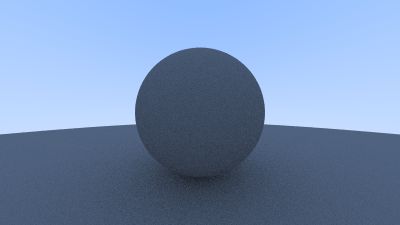

In [10]:
cam.show()


# Code Reduce

In [11]:
from util.sphere import Sphere
from util.camera_diff2 import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:40<00:00,  1.02it/s]


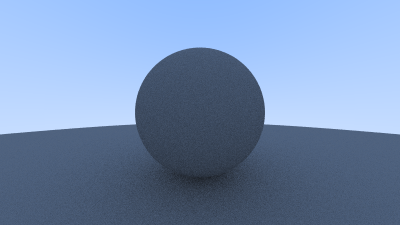

In [12]:
cam.show()